In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-12-09 17:17:32.411516


# Single and double-positive neuron proportions

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [2]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [3]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

### Setup

In [4]:
sys.path.append(str(Path.cwd().resolve().parents[2]))

from config.paths import BASE_DIR

input_dir = BASE_DIR / "data/h5ad/export_04/04a_neurons"
adata_path = input_dir / "scanvi_scvi_adata.h5ad"
bdata_path = input_dir / "seurat_scvi_adata.h5ad"

In [5]:
adata = sc.read_h5ad(adata_path)
bdata = sc.read_h5ad(bdata_path)

# Neighbors graph

In [6]:
adata

AnnData object with n_obs × n_vars = 57016 × 475
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'sample_id', 'output_id', 'region_id', 'slide_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'batch', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1', 'scanvi_labels', 'seurat_labels', 'prediction.score.CGRP.Theta', 'prediction.score.CGRP.Gamma', 'prediction.score.CGRP.Alpha', 'prediction.score.Nonpeptidergic.nociceptors', 'prediction.score.C.LTMR', 'prediction.score.Sst', 'prediction.score.CGRP.Zeta', 'prediction.score.CGRP.Epsilion', 'prediction.score.Proprioceptors', 'prediction.score.Unknown', 'predicti

In [7]:
sc.pp.neighbors(adata, use_rep = 'X_scVI_scanvi_scvi', random_state = 0)
sc.pp.neighbors(bdata, use_rep = 'X_scVI_seurat_scvi', random_state = 0)

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
sc.tl.umap(adata, random_state = 0)
sc.tl.umap(bdata, random_state = 0)

In [9]:
def assign_cell_type_colors(adata, key="cell_type"):
    """
    Assigns a tab10 color palette to a categorical obs field.
    If there are more than 10 categories, the palette cycles.
    """
    # Ensure categorical
    adata.obs[key] = adata.obs[key].astype("category")
    
    cats = adata.obs[key].cat.categories
    n = len(cats)

    # tab10 gives 10 colors; using modulo lets us cycle if n > 1=20
    base_palette = sns.color_palette("tab20", 20)

    palette = [mcolors.to_hex(base_palette[i % 20]) for i in range(n)]

    # assign colors in category order
    adata.uns[f"{key}_colors"] = palette

In [10]:
assign_cell_type_colors(adata,  key="scanvi_labels")
assign_cell_type_colors(adata,  key="seurat_labels")
assign_cell_type_colors(bdata,  key="scanvi_labels")
assign_cell_type_colors(bdata,  key="seurat_labels")

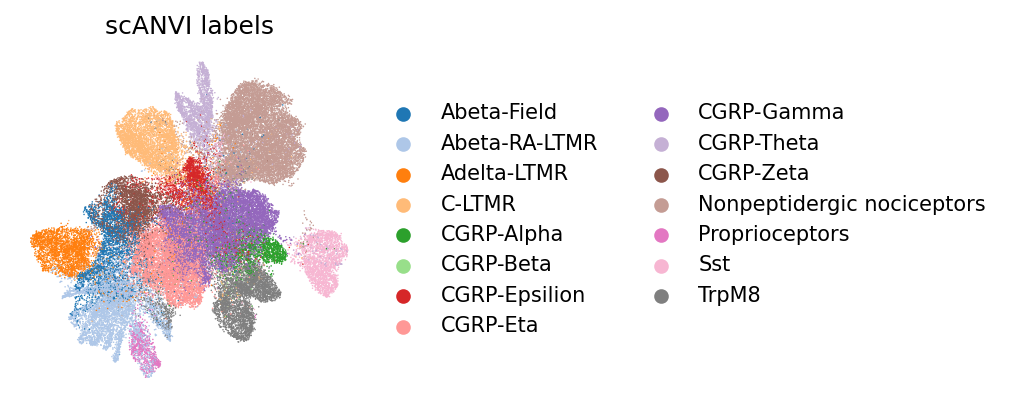

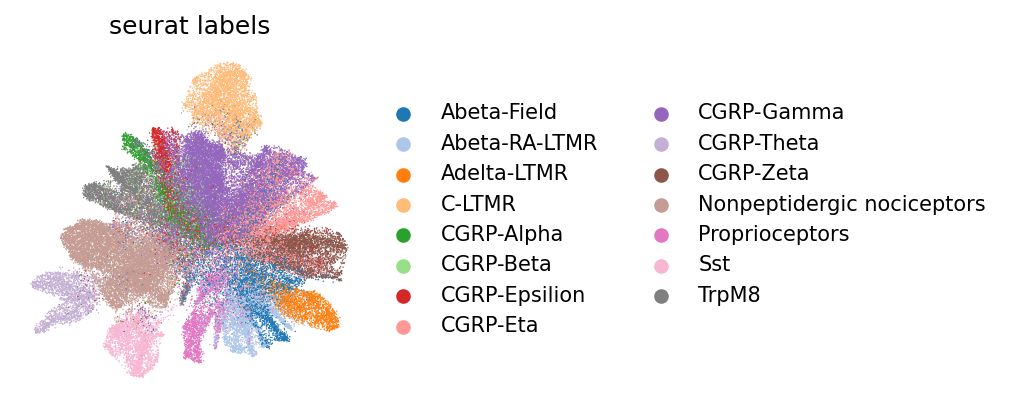

In [11]:
sc.pl.umap(adata, color = 'scanvi_labels', frameon = False, title = 'scANVI labels')
sc.pl.umap(bdata, color = 'seurat_labels', frameon = False, title = 'seurat labels')

# Visualization

In [12]:
#test
#adata = adata[adata.obs['total_counts'] > 1000].copy()
#bdata = bdata[bdata.obs['total_counts'] > 1000].copy()


### Single-dual-positive counts

In [13]:
def plot_tracing_barchart(
    adata,
    egfp_col="EGFP_Seq1_hi",
    dtom_col="dTomato_Seq2_hi",
    dual_col="EGFP_dTomato_dual_hi",
    colors=None,
    figsize=(3, 3)
):
    """
    Plot counts of EGFP+, dTomato+, and dual-positive cells.
    """

    # Default colors
    if colors is None:
        colors = {
            "EGFP": "limegreen",
            "dTomato": "crimson",
            "Dual": "gold",
        }

    # Check columns
    for col in [egfp_col, dtom_col, dual_col]:
        if col not in adata.obs.columns:
            raise ValueError(f"Column `{col}` not found in adata.obs")

    # Extract counts
    n_egfp = adata.obs[egfp_col].sum()
    n_dtom = adata.obs[dtom_col].sum()
    n_dual = adata.obs[dual_col].sum()

    categories = ["EGFP+", "dTomato+", "Dual+"]
    counts = [n_egfp, n_dtom, n_dual]
    plot_colors = [colors["EGFP"], colors["dTomato"], colors["Dual"]]

    # Plot
    plt.figure(figsize=figsize)
    bars = plt.bar(categories, counts, color=plot_colors, edgecolor="black")

    # Add labels above bars
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height}",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.ylabel("Number of cells")
    plt.title("Counts of Single and Dual-Positive Cells")
    plt.tight_layout()
    plt.show()

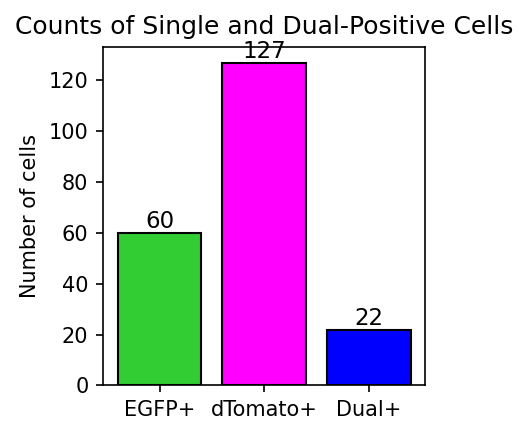

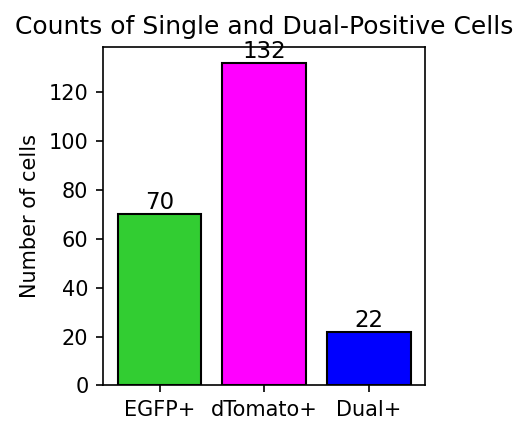

In [14]:
plot_tracing_barchart(
    adata,
    colors={
        "EGFP": "limegreen",
        "dTomato": "magenta",
        "Dual": "blue"
    }
)

plot_tracing_barchart(
    bdata,
    colors={
        "EGFP": "limegreen",
        "dTomato": "magenta",
        "Dual": "blue"
    }
)

### Single-dual-positive proportion

In [15]:
import matplotlib.pyplot as plt

def plot_dual_fraction_among_dtom(
    adata,
    dtom_col="dTomato_Seq2_hi",
    dual_col="EGFP_dTomato_dual_hi",
    colors=None,
    figsize=(3, 3)
):
    """
    Visualize what fraction of dTomato+ cells are dual+.
    Produces both raw counts and a percent bar chart.
    """

    # Default colors
    if colors is None:
        colors = {
            "Single": "crimson",   # dTom only
            "Dual": "gold"         # dTom + EGFP
        }

    # Check columns
    for col in [dtom_col, dual_col]:
        if col not in adata.obs.columns:
            raise ValueError(f"Column `{col}` not found in adata.obs")

    # Boolean masks
    dtom_mask = adata.obs[dtom_col].astype(bool)
    dual_mask = adata.obs[dual_col].astype(bool)

    # Counts
    n_dtom_total = dtom_mask.sum()
    n_dual = (dtom_mask & dual_mask).sum()
    n_dtom_only = n_dtom_total - n_dual

    # Fractions
    frac_dual = n_dual / n_dtom_total if n_dtom_total > 0 else 0
    frac_single = 1 - frac_dual

    categories = ["dTom-only", "Dual+"]
    values = [n_dtom_only, n_dual]
    plot_colors = [colors["Single"], colors["Dual"]]

    # Plot
    plt.figure(figsize=figsize)
    bars = plt.bar(categories, values, color=plot_colors, edgecolor="black")

    # Add labels
    for bar, val in zip(bars, values):
        plt.text(
            bar.get_x() + bar.get_width()/2,
            val,
            f"{val}\n({val/n_dtom_total*100:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=11
        )

    plt.ylabel("Number of cells")
    plt.title(f"Dual+ Fraction Among dTomato+ Cells\nDual = {frac_dual*100:.1f}%")
    plt.tight_layout()
    plt.show()

    return {
        "n_dTom_total": n_dtom_total,
        "n_dual": n_dual,
        "n_dtom_single": n_dtom_only,
        "fraction_dual": frac_dual
    }

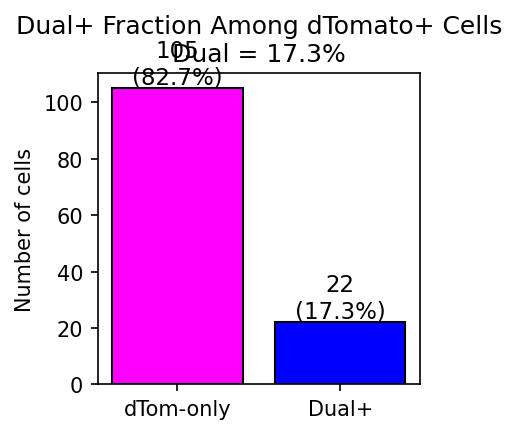

In [16]:
stats = plot_dual_fraction_among_dtom(
    adata,
    colors={
        "Single": "magenta",
        "Dual": "blue"
    }
)

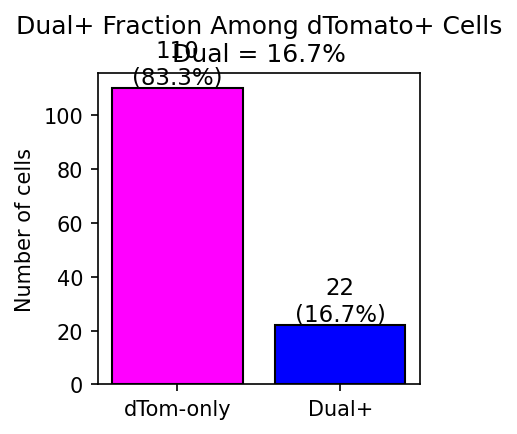

In [17]:
stats = plot_dual_fraction_among_dtom(
    bdata,
    colors={
        "Single": "magenta",
        "Dual": "blue"
    }
)

### UMAP

In [18]:
import matplotlib.pyplot as plt

def plot_umaps(
    adata,
    label_cols,
    true_color_map,
    false_color,
    true_size,
    false_size,
    edgecolor,
    linewidth,
    alpha_false,
    alpha_true,
    figsize=(3, 3),
):
    """
    Plot minimalist UMAPs for boolean label columns.
    No title, no axes, no border.
    """

    if "X_umap" not in adata.obsm:
        raise ValueError("No UMAP found in adata.obsm['X_umap'].")

    x, y = adata.obsm["X_umap"][:, 0], adata.obsm["X_umap"][:, 1]

    for col in label_cols:
        if col not in adata.obs.columns:
            print(f"Column `{col}` not in adata.obs — skipping.")
            continue

        if col not in true_color_map:
            raise ValueError(f"Missing true_color_map entry for `{col}`.")

        true_color = true_color_map[col]
        mask = adata.obs[col].astype(bool).values

        plt.figure(figsize=figsize)

        # Plot FALSE background
        plt.scatter(
            x[~mask],
            y[~mask],
            s=false_size,
            c=false_color,
            linewidths=0,
            alpha=alpha_false,
        )

        # Plot TRUE foreground
        plt.scatter(
            x[mask],
            y[mask],
            s=true_size,
            c=true_color,
            linewidths=linewidth,
            edgecolors=edgecolor,
            alpha=alpha_true,
        )

        ax = plt.gca()
        ax.set_aspect("equal", "box")

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title("")           # remove title
        ax.spines["top"].set_visible(False)
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

        plt.tight_layout()
        plt.show()

In [19]:
labels = ["EGFP_Seq1_hi", "dTomato_Seq2_hi", "EGFP_dTomato_dual_hi"]

true_color_map = {
    "EGFP_Seq1_hi": "limegreen",
    "dTomato_Seq2_hi": "magenta",
    "EGFP_dTomato_dual_hi": "blue",
}

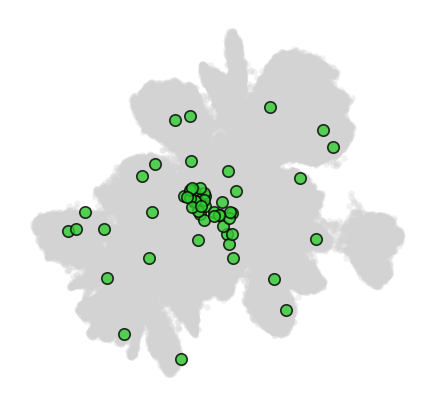

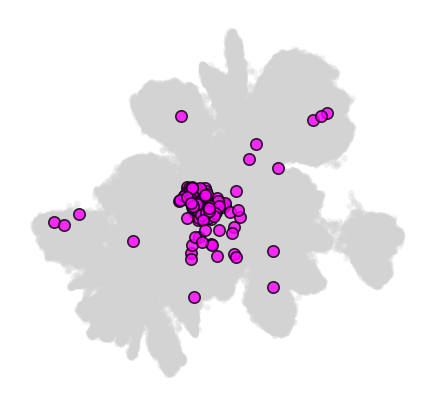

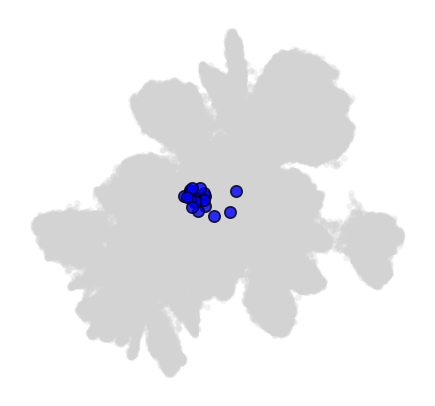

In [20]:
plot_umaps(
    adata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
)

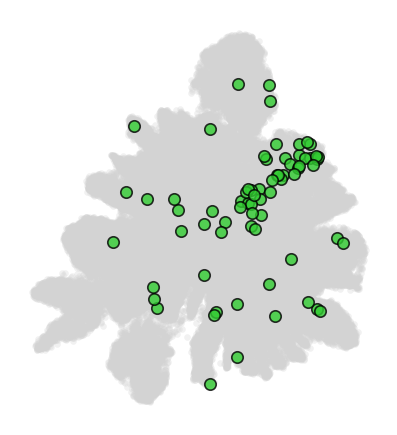

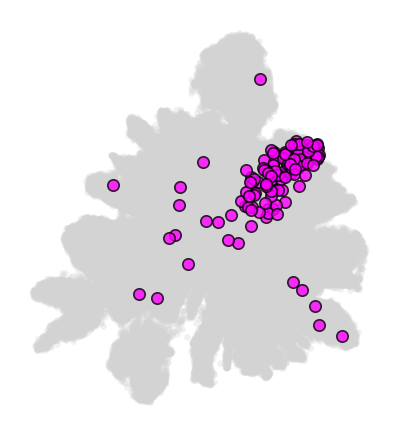

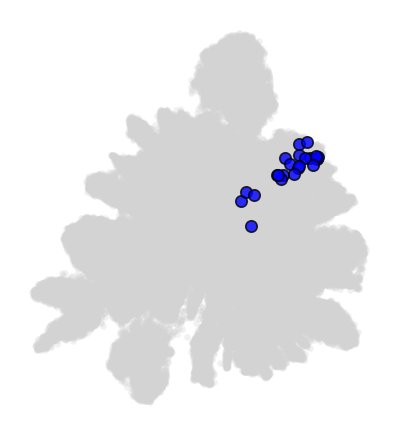

In [21]:
plot_umaps(
    bdata,
    label_cols=labels,
    true_color_map=true_color_map,
    false_color="lightgray",
    true_size=30,
    false_size=10,
    edgecolor="black",
    linewidth=0.8,
    alpha_false=0.3,
    alpha_true=0.8,
)

# Summary

In [22]:
# Boolean masks
egfp = bdata.obs["EGFP_Seq1_hi"].astype(bool)
dtom = bdata.obs["dTomato_Seq2_hi"].astype(bool)
dual = bdata.obs["EGFP_dTomato_dual_hi"].astype(bool)

egfp_single = egfp & ~dtom
dtom_single = dtom & ~egfp
dual_pos    = dual

# Build a small table
df = pd.DataFrame({
    "barcode": bdata.obs.index,
    "seurat_label": bdata.obs["seurat_labels"],
    "scanvi_label": bdata.obs["scanvi_labels"],
    "confidence": bdata.obs["confidence"],
    "EGFP_single": egfp_single.values,
    "dTom_single": dtom_single.values,
    "Dual_positive": dual_pos.values,
})

In [23]:
df[df["EGFP_single"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
aogalboa-1,aogalboa-1,CGRP-Gamma,CGRP-Eta,NaN
cfckmnhc-1,cfckmnhc-1,Nonpeptidergic nociceptors,Nonpeptidergic nociceptors,NaN
ckgddhbd-1,ckgddhbd-1,CGRP-Eta,SGC,NaN
higbejdg-1,higbejdg-1,C-LTMR,SGC,NaN
ahgdffna-1,ahgdffna-1,CGRP-Eta,CGRP-Eta,NaN
akfjbdhd-1,akfjbdhd-1,TrpM8,Pericyte,NaN
canljbbi-1,canljbbi-1,CGRP-Gamma,CGRP-Gamma,NaN
eaiehejo-1,eaiehejo-1,Abeta-Field,Adelta-LTMR,NaN
eckbhagl-1,eckbhagl-1,Nonpeptidergic nociceptors,Pericyte,NaN
ihadecfn-1,ihadecfn-1,CGRP-Gamma,CGRP-Gamma,NaN


In [24]:
df[df["dTom_single"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
achecihm-1,achecihm-1,CGRP-Gamma,CGRP-Gamma,NaN
aemkjdhf-1,aemkjdhf-1,CGRP-Gamma,CGRP-Gamma,NaN
agbmnepe-1,agbmnepe-1,CGRP-Gamma,CGRP-Gamma,High
behbjfkc-1,behbjfkc-1,CGRP-Gamma,Pericyte,NaN
bekmepom-1,bekmepom-1,CGRP-Gamma,CGRP-Gamma,NaN
...,...,...,...,...
dhlbnpjp-1,dhlbnpjp-1,CGRP-Gamma,CGRP-Eta,NaN
gkcjkgon-1,gkcjkgon-1,CGRP-Gamma,CGRP-Gamma,NaN
jmdegfji-1,jmdegfji-1,CGRP-Gamma,CGRP-Gamma,NaN
jmepnhcc-1,jmepnhcc-1,CGRP-Gamma,CGRP-Gamma,NaN


In [25]:
df[df["Dual_positive"]][["barcode", "seurat_label", "scanvi_label", "confidence"]]

,barcode,seurat_label,scanvi_label,confidence
bpoikicj-1,bpoikicj-1,CGRP-Gamma,CGRP-Gamma,High
cbhmmeof-1,cbhmmeof-1,CGRP-Gamma,CGRP-Gamma,High
bmjgagok-1,bmjgagok-1,CGRP-Gamma,CGRP-Gamma,High
ijnggkoc-1,ijnggkoc-1,CGRP-Gamma,CGRP-Gamma,High
llknggjo-1,llknggjo-1,CGRP-Gamma,CGRP-Gamma,High
llmfnafp-1,llmfnafp-1,CGRP-Gamma,CGRP-Gamma,High
llmgffik-1,llmgffik-1,CGRP-Gamma,CGRP-Gamma,High
jjmnhibg-1,jjmnhibg-1,CGRP-Gamma,CGRP-Gamma,NaN
jkabbhfm-1,jkabbhfm-1,CGRP-Gamma,CGRP-Gamma,NaN
aefmnmje-1,aefmnmje-1,CGRP-Gamma,CGRP-Gamma,High


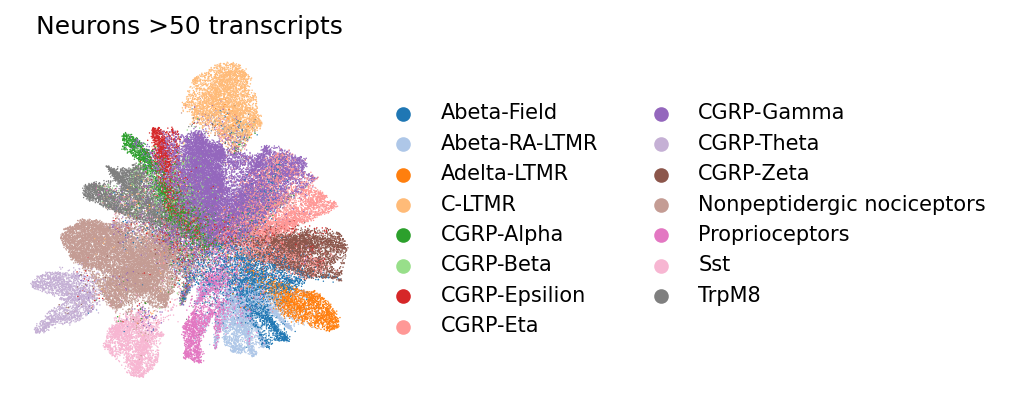

In [30]:
sc.pl.umap(bdata, color = ['seurat_labels'], frameon = False, title = 'Neurons >50 transcripts')

# Export

In [26]:
# Export both scanvi and seurat branches; focus on seurat branch moving forward

## Session info

In [27]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
